Paquetes necesarios

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

Inicializaciones

In [3]:
#Dimensiones de la imagen a crear
ancho = 300
alto = 200

Imagen en grises

In [4]:
#Crea una imagen de un único plano
# Al ser un único plano, se interpreta como nivel de gris (0 negro, 255 blanco)
gris_img = np.zeros((alto,ancho,1), dtype = np.uint8)
#Muestra dimensiones de la imagen creada
print(gris_img.shape)

(200, 300, 1)


Muestra imagen con imshow (OpenCV). Observa que se muestra en ventana independiente

In [5]:
#Muestra la imagen (negra al inicializarse a 0) con las utilidades de OpenCV en una ventana independiente
cv2.imshow('Imagen', gris_img)

cv2.waitKey(-1) # Se detiene hasta pulsar tecla (>0 milisegundos)
cv2.destroyAllWindows() # Destruye todas las ventanas

Muestra imagen con matplotlib

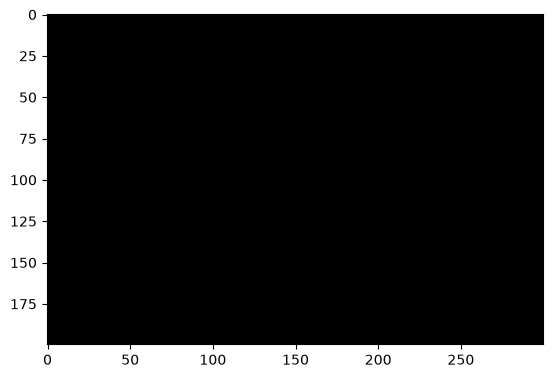

In [6]:
#Muestra la imagen con matplotlib, aparece integrada en el cuaderno
#Es necesario especificar que el mapa de color usado es de grises
plt.imshow(gris_img, cmap='gray') #default: 'viridis'
#plt.imshow(gris_img) #Sin escoger el mapa de colores
plt.show()

#replicar una imagen de gris creando una imagen gris pero con tres planos (RGB)
#img2 = cv2.merge((gris_img,gris_img,gris_img))
#plt.imshow(img2)
#plt.show()

Imagen con tono de gris aleatorio

(200, 300, 1)


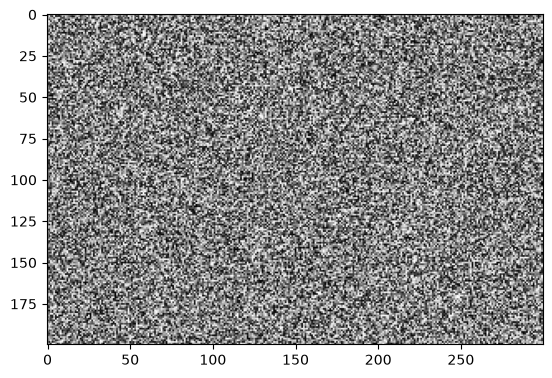

In [7]:
#Crea imagen con un único plano (gris)
gris_img = np.random.randint(255, size=(alto,ancho, 1))
#Muestra dimensiones
print(gris_img.shape)
#Visualiza
plt.imshow(gris_img, cmap='gray') #Visualiza con mapa de color gris
plt.show()

Asignamos valor a los píxeles de una zona concreta

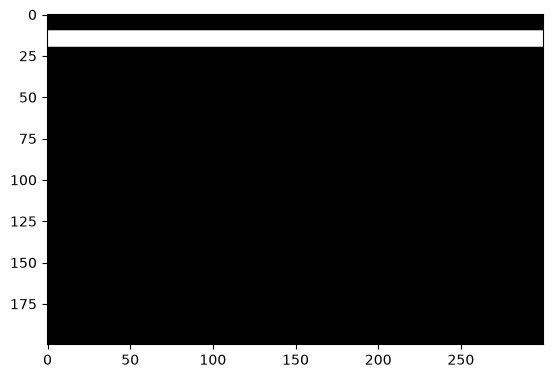

In [8]:
gris_img = np.zeros((alto,ancho,1), dtype = np.uint8)
#Modifica un par de zonas rectangulares de la imagen
gris_img[10:20,0:ancho,0] = 128 #tercer índice especifica un canal (0-2)
#gris_img[110:220,0:20,0] = 28 #
#gris_img[50:70,40:60] = 255 #realmente no es necesario especificar el plano con un único plano

#matplotlib aplica normalización entre lso valores máximo y mínimo de la imagen
#gris_img[:,:,:] = 255 #se verá negra a menos que se especifiquen vmin y vmax

#Muestra la imagen con matplotlib
#Al ser un plano, al visualizar, recordar especificar que el mapa de color usado es de grises
plt.imshow(gris_img, cmap='gray') #Prueba sin especificar el mapa de color
#plt.imshow(gris_img, cmap='gray',vmin=0, vmax=255) #evita el efecto de la normalización de matplotlib
plt.show()

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

Imagen en color

(800, 800, 1)


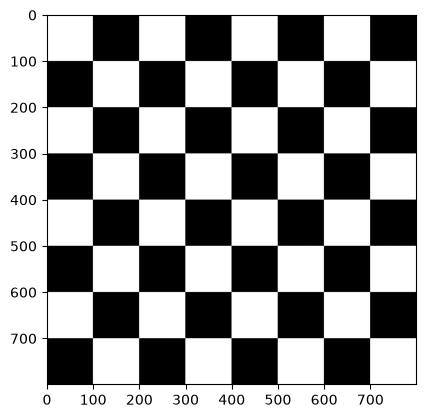

In [9]:
# Sin IA

#Crea una imagen con tres planos
alto = 800
ancho = 800
color_img = np.zeros((alto,ancho,1), dtype = np.uint8)

casilla = 100
x1 = 0
x2 = 100
for i in range(0, 8):
    y1 = 0
    y2 = 100
    if i%2 != 0:
        y1 = 100
        y2 = 200
    for j in range(0, 4):
        color_img[x1:x2, y1:y2, 0] = 255
        y1 += 200
        y2 += 200
    x1 += 100
    x2 += 100

print(color_img.shape)


plt.imshow(color_img, cmap='gray') 
plt.show()




Dimensiones de la imagen: (800, 800, 1)


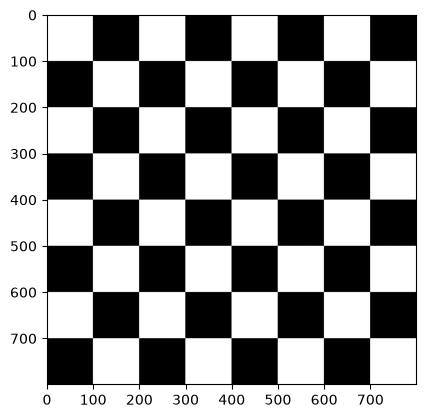

In [10]:
#Con IA

alto, ancho = 800, 800
paso = 100

# 1. Generar matrices con las coordenadas de cada píxel
y, x = np.indices((alto, ancho))

# 2. Aplicar la lógica del ajedrez a toda la matriz simultáneamente
ajedrez_2d = (((y // paso) + (x // paso)) % 2 == 0).astype(np.uint8) * 128

# 3. Ajustar la forma para mantener el plano extra (800, 800, 1)
color_img = np.expand_dims(ajedrez_2d, axis=-1)

print("Dimensiones de la imagen:", color_img.shape)

plt.imshow(color_img, cmap='gray')
plt.show()

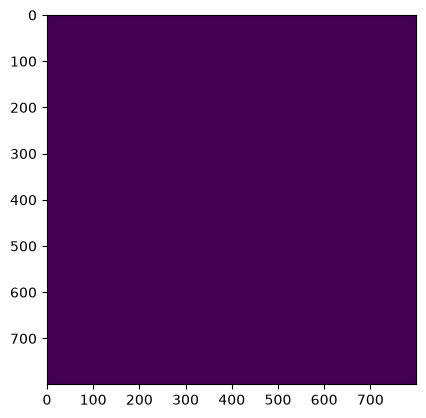

In [11]:
#Modifica el primer plano de color (Rojo, ya que es RGB)
color_img[:,:,0] = 255 
#color_img[:,:,1] = 200 #Prueba otras combinaciones
#color_img[:,:,2] = 255 
plt.imshow(color_img) 
plt.show()

Funciones de dibujo.
OpenCV dispone de funciones específicas para dibujar formas básicas (más información https://docs.opencv.org/4.x/dc/da5/tutorial_py_drawing_functions.html )

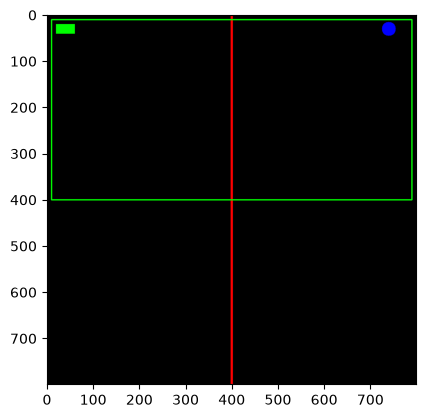

True

In [12]:
#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)

#Línea roja vertical de grosor 3
cv2.line(color_img,(int(ancho/2),0),(int(ancho/2),alto),(255,0,0),3)
#Rectángulo con grosor 2
cv2.rectangle(color_img,(10,10),(ancho-10,int(alto/2)),(0,255,0),2)
#Rectángulo relleno
cv2.rectangle(color_img,(20,20),(60,40),(0,255,0),-1)
#Círculo de radio 15 relleno
cv2.circle(color_img,(ancho-60,30), 15, (0,0,255), -1)
#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

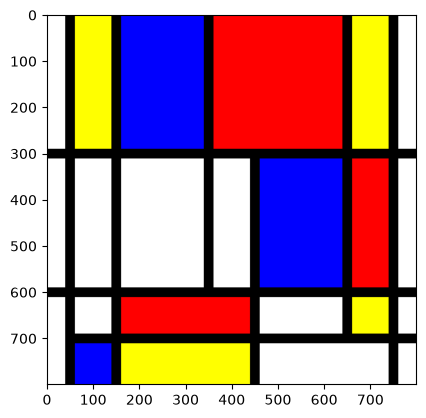

True

In [13]:
#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)
color_img[:] = 255


#Rectángulos
cv2.rectangle(color_img,(60,0),(140,290),(255,255,0),-1)

cv2.rectangle(color_img,(160,0),(340,290),(0,0,255),-1)

cv2.rectangle(color_img,(360,0),(640,290),(255,0,0),-1)

cv2.rectangle(color_img,(660,0),(740,290),(255,255,0),-1)

cv2.rectangle(color_img,(460,310),(640,590),(0,0,255),-1)

cv2.rectangle(color_img,(660,310),(740,590),(255,0,0),-1)

cv2.rectangle(color_img,(160,610),(440,690),(255,0,0),-1)

cv2.rectangle(color_img,(660,610),(740,690),(255,255,0),-1)

cv2.rectangle(color_img,(60,710),(140,800),(0,0,255),-1)

cv2.rectangle(color_img,(160,710),(440,800),(255,255,0),-1)


#Líneas verticales
cv2.line(color_img,(50,0),(50,alto),(0,0,0),20)
cv2.line(color_img,(150,0),(150,alto),(0,0,0),20)
cv2.line(color_img,(350,0),(350,600),(0,0,0),20)
cv2.line(color_img,(450,300),(450,alto),(0,0,0),20)
cv2.line(color_img,(650,0),(650,700),(0,0,0),20)
cv2.line(color_img,(750,0),(750,alto),(0,0,0),20)

#Líneas horizontales
cv2.line(color_img,(0,300),(ancho,300),(0,0,0),20)
cv2.line(color_img,(0,600),(ancho,600),(0,0,0),20)
cv2.line(color_img,(50,700),(ancho,700),(0,0,0),20)
#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

Abrir imagen almacenada en disco

(1200, 1180, 3)


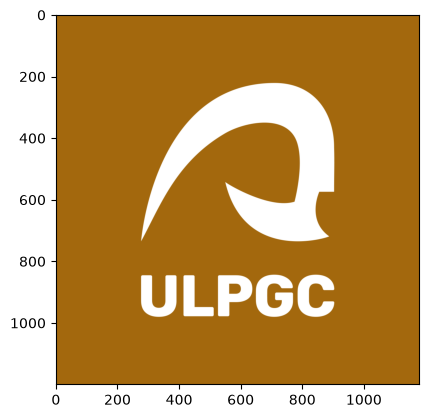

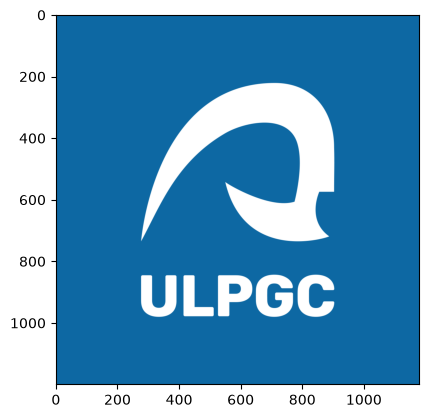

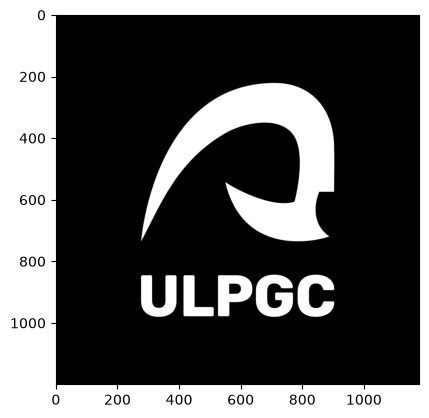

In [14]:
#Carga imagen desde disco
img = cv2.imread('logo_ulpgc_vertical_acronimo_mancheta_azul.png') 
#Dimensiones
print(img.shape)
#Muestra
plt.imshow(img) 
plt.show()

#OpenCV lee las imágenes de disco en formato BGR, por lo que convertimos para visualizr RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) 
plt.show()

#Fuerza lectura en grises
img = cv2.imread('logo_ulpgc_vertical_acronimo_mancheta_azul.png', cv2.IMREAD_GRAYSCALE) 
plt.imshow(img, cmap='gray') 
plt.show()


Abre un archivo de vídeo

In [15]:
# Abre vídeo
vid = cv2.VideoCapture('VermeerFun.mp4') 
  
# En caso de estar abierto
if vid.isOpened():
    while(True):      
        # fotograma a fotograma
        ret, frame = vid.read()

        # Hay nuevo fotograma
        if ret:  
            # Muestra fotograma
            cv2.imshow('Vid', frame)
        
        # Detenemos pulsado ESC
        if cv2.waitKey(20) == 27:
            break
    
    # Libera el objeto de captura
    vid.release()
    # Destruye ventanas
    cv2.destroyAllWindows()

KeyboardInterrupt: 

Muestra entrada de la cámara

In [16]:
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:  
        # Muestra fotograma
        cv2.imshow('Vid', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 

Separa los tres planos de la imagen captada por la webcam y muestra en horizontal

In [17]:
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        #Separamos canales
        b = frame[:,:,0]
        g = frame[:,:,1]
        r = frame[:,:,2]
        #Dimensiones imagen de entrada
        h, w, c = frame.shape

        #Concateamos en horizontal los tres planos del fotograma
        collage = np.hstack((r, g, b))
    
        # Muestra fotograma redimensionando a la mitad para que quepa en pantalla
        cv2.imshow('RGB', cv2.resize(collage, (int(w*1.5),int(h/2)),cv2.INTER_NEAREST))
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 

Evento de ratón para mostrar el valor RGB del píxel

In [18]:
# Función que trata eventos de ratón 
def mouse_events(event, x, y, flags, params):
    global px, py, R, G, B
    px = -1
    # Movimiento del puntero     
    if event==cv2.EVENT_MOUSEMOVE:
        #Valores del píxel, desde la webcam no es BGR
        B = frame[y, x, 0]
        G = frame[y, x, 1]
        R = frame[y, x, 2]  
        # Almacena valores del evento
        px = x
        py = y

     
  

In [19]:
vid = cv2.VideoCapture(0)

# Tipografía para mostrar texto
font = cv2.FONT_HERSHEY_SIMPLEX
  
lanzado = 0 #bandera para primer fotograma
px = -1
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret: 
        # Activa el manejador en el primer fotograma
        if lanzado == 0:
            # Muestra fotograma
            cv2.imshow('Cam', frame)   
            # Define el nombre del manejador del evento
            cv2.setMouseCallback('Cam', mouse_events)
            lanzado = 1
            
        # Muestra valores RGB intentando centrar en el puntero
        if px > -1:
            cv2.putText(frame, '{}'.format(R), (px-45,py-5), font, 0.5, (0, 0, 255), 1)
            cv2.putText(frame, '     {}'.format(G), (px-54,py-5), font, 0.5, (0, 255, 0), 1)
            cv2.putText(frame, '         {}'.format(B), (px-54,py-5), font, 0.5, (255, 0, 0), 1)
            
        cv2.imshow('Cam', frame)   
        
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [21]:
# Lento con retardo

import cv2
import numpy as np

vid = cv2.VideoCapture(0)


while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret: 
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        h, w = frame_gris.shape 

        # 0 oscuro, 255 claro
        min_val = 255
        max_val = 0
        pos_min = (0, 0)
        pos_max = (0, 0)

        for y in range(0, h):
            for x in range(0, w):
                valor = frame_gris[y, x]

                if valor < min_val:
                        min_val = valor
                        pos_min = (x, y) # Guardamos coordenada para dibujar
                        
                if valor > max_val:
                    max_val = valor
                    pos_max = (x, y)
        cv2.circle(frame, pos_min, 15, (255, 0, 0), -1) # Azul oscuro
        cv2.circle(frame, pos_max, 15, (0, 0, 255), -1) # Rojo claro

        cv2.imshow('Vid', frame)
   
    if cv2.waitKey(20) == 27:
        break
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\naiar\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\interactiveshell.py", line 3823, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\naiar\AppData\Local\Temp\ipykernel_26004\1843951934.py", line None, in <module>
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\naiar\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\interactiveshell.py", line 2279, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\naiar\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\ultratb.py", line 1300, in structured_traceback
    return FormattedTB.structured_traceback(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\naiar\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\ultratb.py", line 1166, in structured_traceback
    retu

In [22]:
# Acelerado y fluido

import cv2
import numpy as np

vid = cv2.VideoCapture(0)

while(True):      
    ret, frame = vid.read()

    if ret: 
        # 1. Pasamos a escala de grises
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # 2. Búsqueda optimizada (Sustituye a todo tu bloque 'for')
        min_val, max_val, pos_min, pos_max = cv2.minMaxLoc(frame_gris)

        # 3. Dibujamos los círculos usando las posiciones devueltas
        cv2.circle(frame, pos_min, 15, (255, 0, 0), -1) # Azul en el más oscuro
        cv2.circle(frame, pos_max, 15, (0, 0, 255), -1) # Rojo en el más claro

        cv2.imshow('Vid', frame)
   
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

Pop art
Salida de la webcam "inspirada" en Andy Warhol (Marilyn, https://temasycomentariosartepaeg.blogspot.com/p/autor-andy-warhol-1928-1987-titulo.html)

In [23]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 2x original
collage = np.zeros((h*2,w*2,3), dtype = np.uint8)
tl = collage[0:h,0:w]
tr = collage[0:h,w:w+w]
bl = collage[h:h+h,0:w]
br = collage[h:h+h,w:w+w]

while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]

        #Jugamos con los valores de los planos
        tl[:,:,0] = b
        tl[:,:,1] = g
        tl[:,:,2] = r

        tr[:,:,0] = 255 - r
        tr[:,:,1] = g
        tr[:,:,2] = b
        
        bl[:,:,0] = r
        bl[:,:,1] = 255 - b
        bl[:,:,2] = g

        br[:,:,0] = b
        br[:,:,1] = g
        br[:,:,2] = 255 - r
    
        # Muestra composición
        cv2.imshow('Cam', collage)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 

Transformando la imagen capturada en una colección de círculos, cuyo radio depende de la intensidad promedio de la zona

In [24]:
vid = cv2.VideoCapture(0)

# Se define el número de celdas
ncells = 10
off = int(ncells/2)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        #Dimensiones originales
        h, w, c = frame.shape
        #Redimensiono teniendo en cuenta ncells
        down_frame = cv2.resize(frame, (int(w/ncells),int(h/ncells)),cv2.INTER_NEAREST)
        #Dimensiones reducidas
        h2, w2, c2 = down_frame.shape

        #Separamos canales
        r = down_frame[:,:,0]
        g = down_frame[:,:,1]
        b = down_frame[:,:,2]

        # Creamos imagen negra
        gris_up_frame = np.zeros((h2*ncells,w2*ncells,1), dtype = np.uint8)

        # recorre valores de la imagen reducida
        for y in range(0,h2):
            for x in range(0,w2):
                # La suma de los valores RGB define el radio del círculo
                rad = int ( (r[y,x] + g[y,x] + b[y,x])/(ncells*3*2))
                cv2.circle(gris_up_frame,(x*ncells+off, y*ncells + off), rad, (255,255,255), -1)

    
        # Muestra fotograma resultante
        cv2.imshow('Cam', gris_up_frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

C:\Users\naiar\AppData\Local\Temp\ipykernel_26004\531065525.py:31: RuntimeWarning: overflow encountered in scalar add
  rad = int ( (r[y,x] + g[y,x] + b[y,x])/(ncells*3*2))


KeyboardInterrupt: 

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [ ]:
# Coger tiras verticales cambiarlas de orden y meterle un filtro en cada canal

import cv2
import numpy as np

vid = cv2.VideoCapture(0)
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))
collage = np.zeros((h,w,3), dtype = np.uint8)

# Para que tordos los cortes sean iguales
tercio = int(w/3)
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:

        collage[:, 0:tercio, 0] = frame[:, tercio*2:tercio*3, 2]
        collage[:, 0:tercio, 1] = frame[:, tercio*2:tercio*3, 1]
        collage[:, 0:tercio, 2] = frame[:, tercio*2:tercio*3, 0]

        collage[:, tercio:tercio*2, 0] = 255 - frame[:, 0:tercio, 2]
        collage[:, tercio:tercio*2, 1] = frame[:, 0:tercio, 1]
        collage[:, tercio:tercio*2, 2] = frame[:, 0:tercio, 0]
        
        collage[:, tercio*2:tercio*3, 0] = frame[:, tercio:tercio*2, 2]
        collage[:, tercio*2:tercio*3, 1] = 255 - frame[:, tercio:tercio*2, 0]
        collage[:, tercio*2:tercio*3, 2] = frame[:, tercio:tercio*2, 1]


        cv2.imshow('Vid', collage)
   
    if cv2.waitKey(20) == 27:
        break
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 

: 